# J08 — Redistribution, évaporation, prélèvement racinaire et bilan hydrique

**Physique et hydrodynamique des sols** — S. J. Gumiere

*Atelier du Jour 8 : drainage interne, évaporation analytique, bilan hydrique saisonnier HYDRUS-1D, irrigation*

> Version **instructeur** : code complet et résultats.

## Mise en place

Les projets HYDRUS-1D de référence sont dans `../../hydrus/` et se lisent avec `hydrus_io.py` (dossier `notebooks/`).
Les données propres à l'atelier sont dans `data/`. Convention HYDRUS : flux positif **vers le haut**, profondeurs négatives,
unités cm et jours. Exécutez la cellule suivante pour importer les bibliothèques et définir le loam de référence.

In [1]:
import sys
sys.path.insert(0, "..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import erfc
from hydrus_io import read_tlevel, read_obs_node, read_balance

HYD = "../../hydrus"

# paramètres de van Genuchten du loam (Carsel & Parrish 1988)
thr_loam = 0.078      # teneur en eau résiduelle (-)
ths_loam = 0.430      # teneur en eau à saturation (-)
alpha_loam = 0.036    # alpha (1/cm)
n_loam = 1.56         # n (-)
Ks_loam = 24.96       # conductivité à saturation (cm/j)

# teneur en eau de van Genuchten pour une charge de pression h < 0 (cm)
def vg_theta(h, thr, ths, alpha, n):
    m = 1 - 1 / n
    Se = (1 + (alpha * np.abs(h)) ** n) ** (-m)
    return thr + (ths - thr) * Se

## Exercice 1 — Drainage interne et capacité au champ dynamique  *(≈ 15 min)*

Le projet `J08_redistribution_loam` simule le drainage interne d'un loam de 100 cm initialement à $h = -10$ cm
(surface couverte, flux nul ; drainage libre au bas ; 30 j ; nœuds d'observation à 10, 25, 50 et 90 cm).

1. Lire `OBS_NODE.OUT` (`read_obs_node`) et `T_LEVEL.OUT` (`read_tlevel`). Tracer $\theta(t)$ aux quatre profondeurs et
   superposer $\theta(h=-100)$ et $\theta(h=-330$ cm$)$ du loam.
2. Tracer le flux de drainage $-v_{bot}(t)$ en log-log. Ajuster une loi de puissance $q_d = a\,t^{-b}$ sur le flux de drainage
   et $\theta = a'\,t^{-b'}$ sur $\theta$ à 25 cm (`curve_fit`, $t > 1$ j). Interpréter les exposants.
3. Déterminer le temps $t_{cc}$ pour lequel $q_d$ passe sous 0,1 cm/j (1 mm/j), puis $\theta_{cc}$ à 25 cm à cet instant.
   Comparer à $\theta(-100)$ et $\theta(-330)$. Que devient $t_{cc}$ avec un critère de 0,01 cm/j ?
4. Bilan : stock initial et final (`Volume`), drainage cumulé (`sum(vBot)`), fermeture.

**Lecture des données**

In [2]:
proj = HYD + "/J08_redistribution_loam"
tl = read_tlevel(proj)        # une ligne par pas de temps : vBot, sum(vBot), Volume, ...
ob = read_obs_node(proj)      # colonnes (noeud, variable) ; noeuds 11, 26, 51, 91 = 10, 25, 50, 90 cm

t = tl.index.to_numpy()                   # temps (j)
drainage = -tl["vBot"].to_numpy()         # flux de drainage au bas du profil (cm/j), compté positif vers le bas
theta_10 = ob[(11, "theta")].to_numpy()   # teneur en eau à 10 cm
theta_25 = ob[(26, "theta")].to_numpy()
theta_50 = ob[(51, "theta")].to_numpy()
theta_90 = ob[(91, "theta")].to_numpy()
print(tl[["vBot", "sum(vBot)", "Volume"]].tail())

         vBot  sum(vBot)  Volume
Time                            
28.0 -0.10988    -14.715  26.021
28.5 -0.10751    -14.769  25.967
29.0 -0.10517    -14.821  25.914
29.5 -0.10287    -14.873  25.863
30.0 -0.10061    -14.923  25.813


**1. Teneur en eau aux quatre profondeurs**

theta(-100) = 0.242, theta(-330) = 0.165


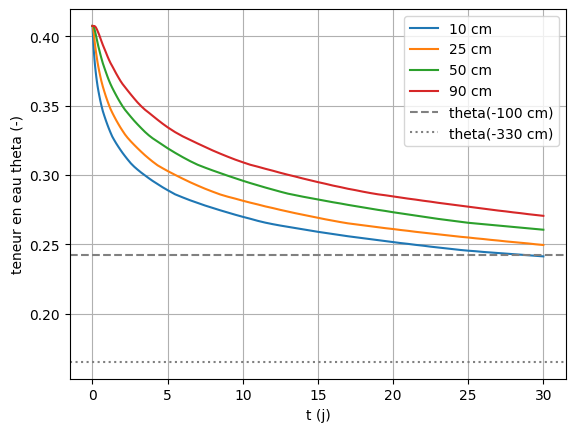

In [3]:
# teneur en eau du loam à h = -100 cm (pF 2) et h = -330 cm (pF 2,5)
theta_100 = vg_theta(-100, thr_loam, ths_loam, alpha_loam, n_loam)
theta_330 = vg_theta(-330, thr_loam, ths_loam, alpha_loam, n_loam)
print(f"theta(-100) = {theta_100:.3f}, theta(-330) = {theta_330:.3f}")

plt.figure()
plt.plot(t, theta_10, label="10 cm")
plt.plot(t, theta_25, label="25 cm")
plt.plot(t, theta_50, label="50 cm")
plt.plot(t, theta_90, label="90 cm")
plt.axhline(theta_100, color="gray", linestyle="--", label="theta(-100 cm)")
plt.axhline(theta_330, color="gray", linestyle=":", label="theta(-330 cm)")
plt.xlabel("t (j)")
plt.ylabel("teneur en eau theta (-)")
plt.legend()
plt.grid(True)
plt.show()

**2. Flux de drainage et lois de puissance**

drainage : q_d = 3.005 t^-0.932 (cm/j)
theta à 25 cm : theta = 0.357 t^-0.104


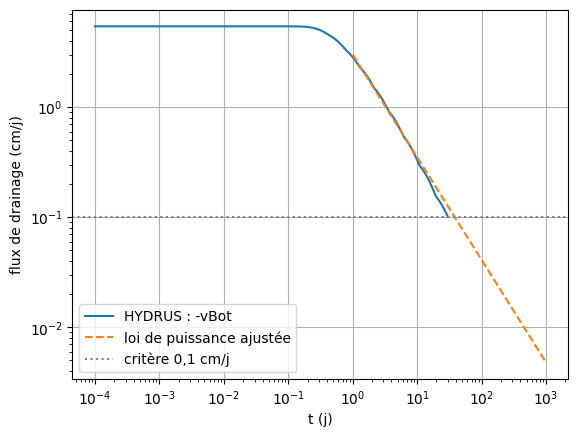

In [4]:
# loi de puissance y = a t^(-b), ajustée par curve_fit
def loi_puissance(t, a, b):
    return a * t ** (-b)

# ajustement sur les temps t > 1 j seulement
apres_1j = t > 1
popt, pcov = curve_fit(loi_puissance, t[apres_1j], drainage[apres_1j], p0=[3, 1])
a_q = popt[0]
b_q = popt[1]
popt, pcov = curve_fit(loi_puissance, t[apres_1j], theta_25[apres_1j], p0=[0.35, 0.1])
a_t = popt[0]
b_t = popt[1]
print(f"drainage : q_d = {a_q:.3f} t^-{b_q:.3f} (cm/j)")
print(f"theta à 25 cm : theta = {a_t:.3f} t^-{b_t:.3f}")

t_courbe = np.logspace(0, 3, 100)
plt.figure()
plt.loglog(t, drainage, label="HYDRUS : -vBot")
plt.loglog(t_courbe, loi_puissance(t_courbe, a_q, b_q), "--", label="loi de puissance ajustée")
plt.axhline(0.1, color="gray", linestyle=":", label="critère 0,1 cm/j")
plt.xlabel("t (j)")
plt.ylabel("flux de drainage (cm/j)")
plt.legend()
plt.grid(True)
plt.show()

**3. Capacité au champ dynamique (critère de flux)**

In [5]:
# on inverse la loi de puissance : q_d = a t^(-b)  ->  t = (a / q_d)^(1/b)
t_cc = (a_q / 0.1) ** (1 / b_q)
theta_cc = loi_puissance(t_cc, a_t, b_t)
print(f"Critère 0,1 cm/j : t_cc = {t_cc:.1f} j, theta_cc(25 cm) = {theta_cc:.3f}")
print(f"à comparer à theta(-100) = {theta_100:.3f} et theta(-330) = {theta_330:.3f}")

t_cc_001 = (a_q / 0.01) ** (1 / b_q)
print(f"Critère 0,01 cm/j : t_cc = {t_cc_001:.0f} j (irréaliste à l'échelle d'une saison)")

Critère 0,1 cm/j : t_cc = 38.5 j, theta_cc(25 cm) = 0.244
à comparer à theta(-100) = 0.242 et theta(-330) = 0.165
Critère 0,01 cm/j : t_cc = 455 j (irréaliste à l'échelle d'une saison)


**4. Bilan de masse**

In [6]:
V_initial = tl["Volume"].iloc[0]        # stock d'eau du profil (cm) au premier pas de temps
V_final = tl["Volume"].iloc[-1]         # stock à 30 j
D_cumule = -tl["sum(vBot)"].iloc[-1]    # drainage cumulé (cm), positif vers le bas
perte = V_initial - V_final
print(f"Stock initial {V_initial:.2f} cm, final {V_final:.2f} cm : perte {perte:.2f} cm")
print(f"Drainage cumulé {D_cumule:.2f} cm ; écart de fermeture {perte - D_cumule:+.3f} cm")

bal = read_balance(proj)
print("Erreur relative de bilan HYDRUS (WatBalR) max :", np.max(np.abs(bal["WatBalR"])), "%")

Stock initial 40.73 cm, final 25.81 cm : perte 14.92 cm
Drainage cumulé 14.92 cm ; écart de fermeture -0.001 cm
Erreur relative de bilan HYDRUS (WatBalR) max : 0.001 %


**Commentaire (instructeur).** Le flux de drainage décroît presque en $1/t$ ($b \approx 0{,}93$) et $\theta$ très lentement ($b' \approx 0{,}10$) : le drainage
« ne s'arrête jamais », il devient seulement négligeable. Avec le critère de 1 mm/j, $t_{cc} \approx 38$ j et $\theta_{cc} \approx 0{,}244$,
soit $\theta(h = -100$ cm$)$ : pour ce loam, la capacité au champ classique (pF 2) est retrouvée ; $-330$ cm (pF 2,5) sous-estimerait la réserve de 30 \%.
Le bilan ferme à mieux que 0,01 cm (drainage libre, pas d'autre flux).

## Exercice 2 — Évaporation : solution analytique par transformée de Kirchhoff  *(≈ 15 min)*

Modèle linéarisé (Gardner 1959 ; notes GAE-1004 §3.7) : $K = K_s e^{\alpha_G h}$ et $\theta - \theta_r = (\theta_s - \theta_r)e^{\alpha_G h}$,
donc $D = K_s/[\alpha_G(\theta_s-\theta_r)]$ est constante et $\Phi = \int_{-\infty}^h K\,dh = K/\alpha_G$. Pour un profil semi-infini
initialement à $h_i$ ($\Phi_i = K(h_i)/\alpha_G$) dont la surface sèche brusquement ($\Phi = 0$), le flux d'évaporation vaut

$$e_{sol}(t) = \frac{\Phi_i}{\sqrt{Dt}}\left[\frac{e^{-x^2}}{\sqrt{\pi}} - x\,\mathrm{erfc}(x)\right], \qquad x = \frac{\alpha_G}{2}\sqrt{Dt},$$

et, sans gravité ($\alpha_G \to 0$ dans le crochet), $e_{sol} = \Phi_i/\sqrt{\pi D t} = S_d/(2\sqrt t)$ avec la désorptivité $S_d = 2\Phi_i/\sqrt{\pi D}$.

1. Calculer $D$, $K_i$, $\Phi_i$ et $S_d$ pour le loam ($K_s = 24{,}96$ cm/j, $\alpha_G = 0{,}02$ cm$^{-1}$, $\theta_s = 0{,}43$,
   $\theta_r = 0{,}078$, $h_i = -50$ cm), puis écrire la fonction `e_kirchhoff(t, D, Phi_i, alphaG)` (formule ci-dessus).
2. Évaporation réelle à deux stades : $e(t) = \min(e_p, e_{sol}(t))$. Pour $e_p$ = 0,3, 0,5 et 0,8 cm/j, tracer $e(t)$ et le cumul $E(t)$
   (méthode des trapèzes) sur 10 j ; déterminer la durée $t_1$ du stade 1 et $E(10$ j$)$.
3. Vérifier le comportement en $t^{-1/2}$ : pente de $\log e_{sol}$ vs $\log t$ sur 0,001–0,01 j puis sur 0,05–0,5 j, avec et sans gravité.
   À partir de quel temps la gravité compte-t-elle ($x = \tfrac{\alpha_G}{2}\sqrt{Dt} \approx 0{,}1$) ?
4. Sensibilité : refaire pour $\alpha_G$ = 0,01 et 0,05 cm$^{-1}$ et pour $h_i$ = $-20$ et $-100$ cm. Commenter.

**1. Paramètres du modèle linéarisé et flux limité par le sol**

In [7]:
Ks = 24.96       # cm/j
alphaG = 0.02    # 1/cm
ths = 0.43
thr = 0.078
hi = -50.0       # charge initiale (cm)

# diffusivité constante (cm²/j), conductivité et potentiel de Kirchhoff initiaux, désorptivité
D = Ks / (alphaG * (ths - thr))
K_i = Ks * np.exp(alphaG * hi)
Phi_i = K_i / alphaG
S_d = 2 * Phi_i / np.sqrt(np.pi * D)
print(f"D = {D:.0f} cm²/j ; K_i = {K_i:.2f} cm/j ; Phi_i = {Phi_i:.1f} cm²/j ; S_d = {S_d:.2f} cm/j^0.5")

# flux d'évaporation limité par le sol (cm/j) : solution de Kirchhoff avec gravité
def e_kirchhoff(t, D, Phi_i, alphaG):
    x = 0.5 * alphaG * np.sqrt(D * t)
    e = Phi_i / np.sqrt(D * t) * (np.exp(-x ** 2) / np.sqrt(np.pi) - x * erfc(x))
    return e

print("e_sol(1 j) =", round(e_kirchhoff(1.0, D, Phi_i, alphaG), 3), "cm/j")

D = 3545 cm²/j ; K_i = 9.18 cm/j ; Phi_i = 459.1 cm²/j ; S_d = 8.70 cm/j^0.5
e_sol(1 j) = 1.216 cm/j


**2. Évaporation à deux stades**

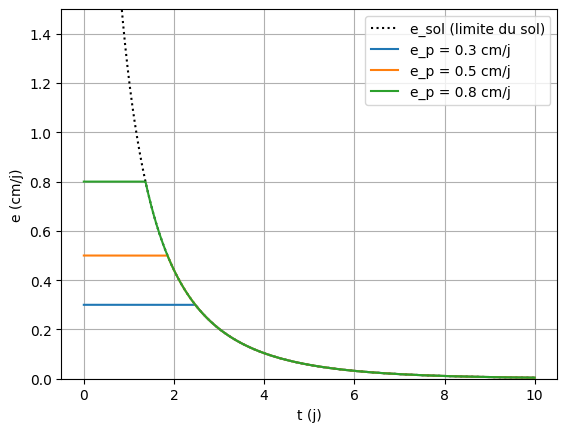

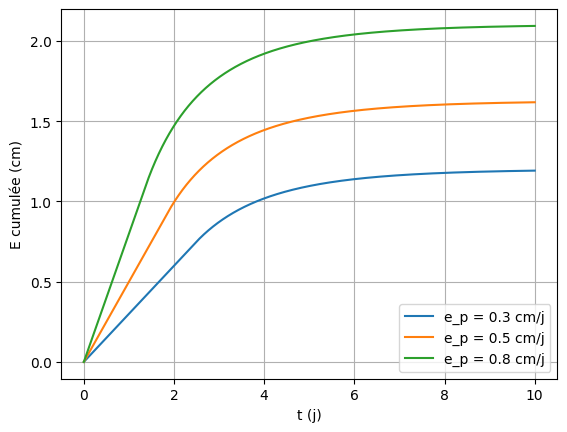

   e_p  t1_j  E_stade1  E_10j  E_potentielle
0  0.3  2.47      0.74   1.19            3.0
1  0.5  1.86      0.93   1.62            5.0
2  0.8  1.37      1.09   2.09            8.0


In [8]:
t = np.linspace(1e-4, 10, 5000)
e_sol = e_kirchhoff(t, D, Phi_i, alphaG)

liste_ep = [0.3, 0.5, 0.8]
cumuls = []
resultats = []
plt.figure()
plt.plot(t, e_sol, "k:", label="e_sol (limite du sol)")
for ep in liste_ep:
    # stade 1 : e = e_p (limité par l'atmosphère) ; stade 2 : e = e_sol (limité par le sol)
    e = np.minimum(ep, e_sol)
    # cumul E(t) par la méthode des trapèzes
    E = np.zeros(len(t))
    for i in range(1, len(t)):
        E[i] = E[i - 1] + 0.5 * (e[i - 1] + e[i]) * (t[i] - t[i - 1])
    # fin du stade 1 : premier instant où e_sol passe sous e_p
    t_stade2 = t[e_sol < ep]
    t1 = t_stade2[0]
    cumuls.append(E)
    resultats.append(dict(e_p=ep, t1_j=t1, E_stade1=ep * t1, E_10j=E[-1], E_potentielle=ep * 10))
    plt.plot(t, e, label=f"e_p = {ep} cm/j")
plt.ylim(0, 1.5)
plt.xlabel("t (j)")
plt.ylabel("e (cm/j)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
for i in range(3):
    plt.plot(t, cumuls[i], label=f"e_p = {liste_ep[i]} cm/j")
plt.xlabel("t (j)")
plt.ylabel("E cumulée (cm)")
plt.legend()
plt.grid(True)
plt.show()

print(pd.DataFrame(resultats).round(2))

**3. Comportement en t^(-1/2) et rôle de la gravité**

In [9]:
# flux sans gravité (alphaG -> 0 dans le crochet) : e = Phi_i / sqrt(pi D t)
def e_sans_gravite(t, D, Phi_i):
    return Phi_i / np.sqrt(np.pi * D * t)

for t_debut, t_fin in [(0.001, 0.01), (0.05, 0.5)]:
    tt = np.logspace(np.log10(t_debut), np.log10(t_fin), 50)
    # pente de la droite log(e) en fonction de log(t) (régression linéaire)
    pente_avec = np.polyfit(np.log(tt), np.log(e_kirchhoff(tt, D, Phi_i, alphaG)), 1)[0]
    pente_sans = np.polyfit(np.log(tt), np.log(e_sans_gravite(tt, D, Phi_i)), 1)[0]
    print(f"pente log-log sur {t_debut}-{t_fin} j : avec gravité {pente_avec:.3f}, sans gravité {pente_sans:.3f}")

# temps pour lequel x = alphaG/2 sqrt(D t) vaut 0,1
t_x = (0.1 / (0.5 * alphaG)) ** 2 / D
print(f"x = 0,1 atteint à t = {t_x:.3f} j : au-delà, la gravité accélère la décroissance de e_sol")

pente log-log sur 0.001-0.01 j : avec gravité -0.531, sans gravité -0.500
pente log-log sur 0.05-0.5 j : avec gravité -0.756, sans gravité -0.500
x = 0,1 atteint à t = 0.028 j : au-delà, la gravité accélère la décroissance de e_sol


**4. Sensibilité à alpha_G et à h_i**

alphaG = 0.01, h_i = -50 : D = 7091 cm²/j, S_d = 20.29 cm/j^0.5, e_sol(1 j) = 4.320 cm/j
alphaG = 0.02, h_i = -50 : D = 3545 cm²/j, S_d = 8.70 cm/j^0.5, e_sol(1 j) = 1.216 cm/j
alphaG = 0.05, h_i = -50 : D = 1418 cm²/j, S_d = 1.23 cm/j^0.5, e_sol(1 j) = 0.066 cm/j
alphaG = 0.02, h_i = -20 : D = 3545 cm²/j, S_d = 15.85 cm/j^0.5, e_sol(1 j) = 2.216 cm/j
alphaG = 0.02, h_i = -100 : D = 3545 cm²/j, S_d = 3.20 cm/j^0.5, e_sol(1 j) = 0.447 cm/j


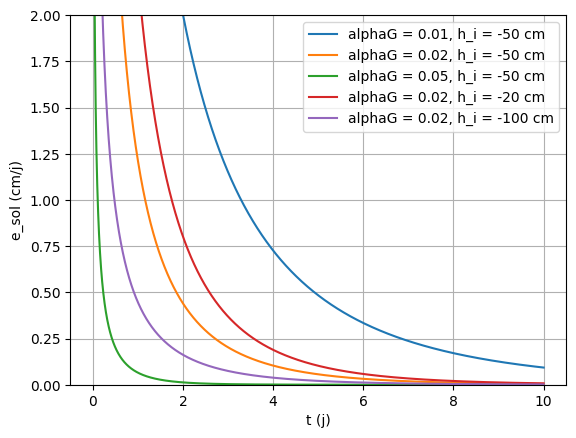

In [10]:
plt.figure()
for alpha_cas, hi_cas in [(0.01, -50), (0.02, -50), (0.05, -50), (0.02, -20), (0.02, -100)]:
    D_cas = Ks / (alpha_cas * (ths - thr))
    Phi_cas = Ks * np.exp(alpha_cas * hi_cas) / alpha_cas
    S_d_cas = 2 * Phi_cas / np.sqrt(np.pi * D_cas)
    e_1j = e_kirchhoff(1.0, D_cas, Phi_cas, alpha_cas)
    print(f"alphaG = {alpha_cas}, h_i = {hi_cas} : D = {D_cas:.0f} cm²/j, S_d = {S_d_cas:.2f} cm/j^0.5, e_sol(1 j) = {e_1j:.3f} cm/j")
    plt.plot(t, e_kirchhoff(t, D_cas, Phi_cas, alpha_cas), label=f"alphaG = {alpha_cas}, h_i = {hi_cas} cm")
plt.ylim(0, 2)
plt.xlabel("t (j)")
plt.ylabel("e_sol (cm/j)")
plt.legend()
plt.grid(True)
plt.show()

**Commentaire (instructeur).** La pente log-log vaut exactement $-0{,}5$ sans gravité ; avec gravité elle vaut $-0{,}5$ aux temps très courts ($x \ll 1$, $t < 0{,}03$ j
pour ce loam à $K_s$ élevé) puis se raidit ($-0{,}76$ sur 0,05–0,5 j) : le stade 2 en $t^{-1/2}$ n'est qu'un comportement limite.
Le stade 1 dure d'autant moins que $e_p$ est grand ($t_1 \propto 1/e_p^2$ sans gravité) ; le cumul à 10 j varie peu avec $e_p$
(1,2 à 2,1 cm) : au-delà du stade 1, c'est le sol qui commande. Un $\alpha_G$ grand (sol grossier, $K$ chute vite) ou un profil
initialement sec ($h_i = -100$) réduisent fortement $\Phi_i$ et donc la désorptivité.

## Exercice 3 — Bilan hydrique d'une saison de maïs (HYDRUS-1D)  *(≈ 20 min)*

Le projet `J08_saison_culture_loam` simule 120 j de maïs sur un loam de 150 cm (condition atmosphérique avec ruissellement,
`hCritA` = 15 000 cm, drainage libre, Feddes maïs, racines linéaires 0–60 cm, $h_0 = -200$ cm). La météo est dans `data/J08_meteo_saison.csv`
(mm/j) : `pluie_mm`, `ET0_mm`, `Kc`, `LAI`, `ETc_mm`, `Ep_mm`, `Tp_mm`.

1. Recalculer $ET_c = K_c\,ET_0$, $E_p = ET_c\,e^{-0{,}463\,LAI}$ et $T_p = ET_c - E_p$ ; vérifier l'accord avec le fichier
   (écart max) et calculer les totaux saisonniers (mm).
2. Lire `T_LEVEL.OUT` : à $t = 120$ j, extraire `sum(Infil)`, `sum(Evap)`, `sum(vRoot)`, `sum(vBot)`, `sum(RunOff)`, `Volume` (initial et final).
   Écrire le bilan $P = I + R$, $\Delta S = I - E_a - T_a - D$ et vérifier la fermeture avec $\Delta$`Volume` ; calculer $E_a/E_p$ et $T_a/T_p$.
   Vérifier `WatBalR` dans `BALANCE.OUT`.
3. Indice de stress journalier : interpoler `sum(vRoot)` à la fin de chaque jour, en déduire $T_a$ journalier et $T_a/T_p$ ;
   tracer avec la pluie ; lister les jours où $T_a/T_p < 0{,}5$.
4. Lire `OBS_NODE.OUT` : $\theta(t)$ à 10, 30, 60, 100 cm avec $\theta_{cc} = \theta(-100)$, $\theta_{pf} = \theta(-15\,000)$ et le seuil
   $\theta_{pf} + 0{,}5(\theta_{cc} - \theta_{pf})$.
5. Avec `data/J08_tensiometres.csv` (charges mesurées à 4 dates sur 0–60 cm), calculer $T_a/T_p = \omega = \int \alpha(h)\,b(z)\,dz$
   par la fonction de Feddes non compensée (P0 = $-15$, POpt = $-30$, P2H = $-325$, P2L = $-600$, P3 = $-8000$ cm ; $h_3$ interpolé selon
   le $T_p$ du jour) avec $b(z)$ linéaire décroissante sur 0–60 cm, chaque tensiomètre représentant une tranche de 10 cm. Le projet HYDRUS
   utilise $\omega_c = 1$ (aucune compensation, bloc G de `SELECTOR.IN`) : comparer au rapport instantané `vRoot/rRoot` de `T_LEVEL.OUT`
   au même instant et discuter les sources d'écart. À titre théorique seulement : que donnerait une compensation avec $\omega_c = 0{,}5$
   ($T_a/T_p = \min(1, \omega/\omega_c)$, Šimůnek & Hopmans 2009) ?

**Lecture des données**

In [11]:
met = pd.read_csv("data/J08_meteo_saison.csv")
proj = HYD + "/J08_saison_culture_loam"
tl = read_tlevel(proj)        # flux et cumuls à chaque pas de temps
ob = read_obs_node(proj)      # noeuds 11, 31, 61, 101 = 10, 30, 60, 100 cm
print(met.head())
print(tl[["sum(Infil)", "sum(Evap)", "sum(vRoot)", "sum(vBot)", "Volume"]].tail(3))

   jour  pluie_mm  ET0_mm   Kc   LAI  ETc_mm  Ep_mm  Tp_mm
0     1       0.4    3.36  0.4  0.20    1.34   1.22   0.12
1     2       0.0    2.86  0.4  0.22    1.14   1.03   0.11
2     3      34.4    3.61  0.4  0.23    1.44   1.30   0.15
3     4       0.0    3.73  0.4  0.25    1.49   1.33   0.16
4     5       0.0    2.61  0.4  0.26    1.04   0.92   0.12


         sum(Infil)  sum(Evap)  sum(vRoot)  sum(vBot)  Volume
Time                                                         
119.750       39.16     12.285      26.498    -2.2817  26.991
119.875       39.16     12.299      26.513    -2.2840  26.959
120.000       39.16     12.314      26.529    -2.2862  26.926


**1. Partition de l'évapotranspiration en Ep et Tp**

In [12]:
k = 0.463    # coefficient d'extinction de Beer-Lambert (valeur HYDRUS)
ETc = met["Kc"] * met["ET0_mm"]
Ep = ETc * np.exp(-k * met["LAI"])
Tp = ETc - Ep

ecart_ETc = np.max(np.abs(ETc - met["ETc_mm"]))
ecart_Ep = np.max(np.abs(Ep - met["Ep_mm"]))
ecart_Tp = np.max(np.abs(Tp - met["Tp_mm"]))
print(f"écart max avec le fichier : ETc {ecart_ETc:.3f} mm ; Ep {ecart_Ep:.3f} mm ; Tp {ecart_Tp:.3f} mm")

totaux = met[["pluie_mm", "ET0_mm", "ETc_mm", "Ep_mm", "Tp_mm"]].sum()
print("Totaux saisonniers (mm) :")
print(totaux.round(1))

écart max avec le fichier : ETc 0.010 mm ; Ep 0.008 mm ; Tp 0.009 mm
Totaux saisonniers (mm) :
pluie_mm    391.6
ET0_mm      583.8
ETc_mm      516.6
Ep_mm       145.0
Tp_mm       371.6
dtype: float64


**2. Bilan hydrique à 120 j**

In [13]:
fin = tl.iloc[-1]              # dernière ligne de T_LEVEL.OUT : t = 120 j (cumuls en cm)
I = fin["sum(Infil)"]          # infiltration
Ea = fin["sum(Evap)"]          # évaporation réelle
Ta = fin["sum(vRoot)"]         # transpiration réelle (prélèvement racinaire)
Dr = -fin["sum(vBot)"]         # drainage, compté positif vers le bas
R = fin["sum(RunOff)"]         # ruissellement
V_initial = tl["Volume"].iloc[0]
V_final = fin["Volume"]

# pluie et demandes potentielles de la saison, converties en cm
P = totaux["pluie_mm"] / 10
Ep_tot = totaux["Ep_mm"] / 10
Tp_tot = totaux["Tp_mm"] / 10

dS_flux = I - Ea - Ta - Dr
dS_volume = V_final - V_initial
print(f"P = {P:.3f} cm ; I = {I:.3f} cm ; R = {R:.3f} cm ; P - I - R = {P - I - R:+.3f} cm")
print(f"Ea = {Ea:.3f} cm ; Ta = {Ta:.3f} cm ; D = {Dr:.3f} cm")
print(f"dS = I - Ea - Ta - D = {dS_flux:.3f} cm ; dS = Volume final - initial = {dS_volume:.3f} cm")
print(f"erreur de fermeture = {dS_flux - dS_volume:.3f} cm")
print(f"Ea/Ep = {Ea / Ep_tot:.3f} ; Ta/Tp = {Ta / Tp_tot:.3f}")

bal = read_balance(proj)
print(f"WatBalR max = {np.max(np.abs(bal['WatBalR'])):.3f} %")

P = 39.160 cm ; I = 39.160 cm ; R = 0.000 cm ; P - I - R = -0.000 cm
Ea = 12.314 cm ; Ta = 26.529 cm ; D = 2.286 cm
dS = I - Ea - Ta - D = -1.969 cm ; dS = Volume final - initial = -2.025 cm
erreur de fermeture = 0.056 cm
Ea/Ep = 0.849 ; Ta/Tp = 0.714
WatBalR max = 0.180 %


**3. Indice de stress journalier Ta/Tp**

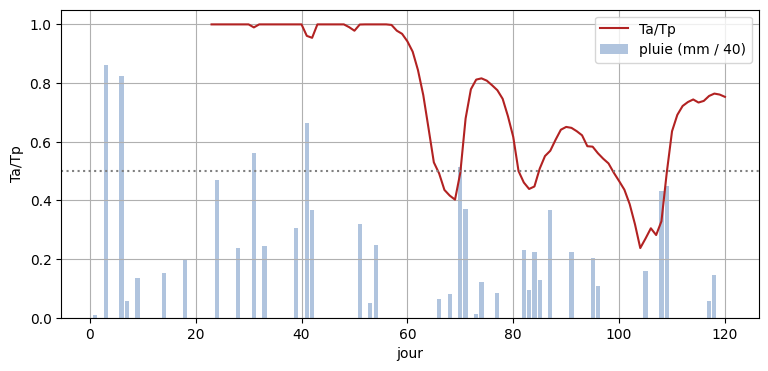

Jours avec Ta/Tp < 0,5 : [66, 67, 68, 69, 70, 82, 83, 84, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109]
nombre de jours de stress sévère : 19 ; Ta/Tp moyen sur la saison = 0.714


In [14]:
jours_fin = np.arange(0, 121)      # fin de chaque jour (0 = état initial)
jours = np.arange(1, 121)          # numéro du jour

# transpiration réelle cumulée à la fin de chaque jour, puis transpiration de chaque jour (cm)
Ta_cum = np.interp(jours_fin, tl.index, tl["sum(vRoot)"])
Ta_j = np.diff(Ta_cum)
Tp_j = met["Tp_mm"].to_numpy() / 10

# indice de stress Ta/Tp (non défini quand la demande Tp est quasi nulle)
ratio = np.full(120, np.nan)
for j in range(120):
    if Tp_j[j] > 0.05:
        ratio[j] = Ta_j[j] / Tp_j[j]

plt.figure(figsize=(9, 4))
plt.bar(jours, met["pluie_mm"] / 40, color="lightsteelblue", label="pluie (mm / 40)")
plt.plot(jours, ratio, color="firebrick", label="Ta/Tp")
plt.axhline(0.5, color="gray", linestyle=":")
plt.xlabel("jour")
plt.ylabel("Ta/Tp")
plt.legend()
plt.grid(True)
plt.show()

jours_stress = []
for j in range(120):
    if ratio[j] < 0.5:
        jours_stress.append(j + 1)
print("Jours avec Ta/Tp < 0,5 :", jours_stress)
print(f"nombre de jours de stress sévère : {len(jours_stress)} ; Ta/Tp moyen sur la saison = {Ta_j.sum() / Tp_j.sum():.3f}")

**4. Teneur en eau aux quatre profondeurs et seuils**

theta_cc = 0.242, theta_pf = 0.088, RU(0-60 cm) = 9.2 cm


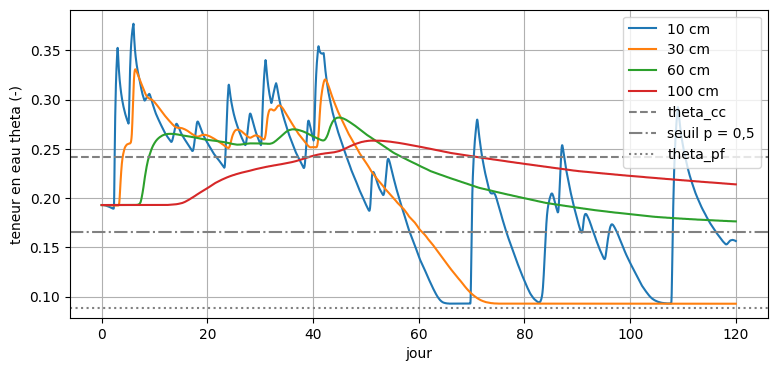

In [15]:
theta_cc = vg_theta(-100, thr_loam, ths_loam, alpha_loam, n_loam)       # capacité au champ (pF 2)
theta_pf = vg_theta(-15000, thr_loam, ths_loam, alpha_loam, n_loam)     # point de flétrissement (pF 4,2)
seuil_theta = theta_pf + 0.5 * (theta_cc - theta_pf)                     # seuil p = 0,5
print(f"theta_cc = {theta_cc:.3f}, theta_pf = {theta_pf:.3f}, RU(0-60 cm) = {(theta_cc - theta_pf) * 60:.1f} cm")

plt.figure(figsize=(9, 4))
plt.plot(ob.index, ob[(11, "theta")], label="10 cm")
plt.plot(ob.index, ob[(31, "theta")], label="30 cm")
plt.plot(ob.index, ob[(61, "theta")], label="60 cm")
plt.plot(ob.index, ob[(101, "theta")], label="100 cm")
plt.axhline(theta_cc, color="gray", linestyle="--", label="theta_cc")
plt.axhline(seuil_theta, color="gray", linestyle="-.", label="seuil p = 0,5")
plt.axhline(theta_pf, color="gray", linestyle=":", label="theta_pf")
plt.xlabel("jour")
plt.ylabel("teneur en eau theta (-)")
plt.legend()
plt.grid(True)
plt.show()

**5. Fonction de Feddes sur les tensiomètres**

In [16]:
tens = pd.read_csv("data/J08_tensiometres.csv")
print(tens.head(6))

# fonction de réduction de Feddes : alpha = 0 (pas de prélèvement) à 1 (prélèvement optimal)
def feddes(h, h1, h2, h3, h4):
    if h >= h1 or h <= h4:
        alpha = 0.0
    elif h > h2:
        alpha = (h - h1) / (h2 - h1)
    elif h >= h3:
        alpha = 1.0
    else:
        alpha = (h - h4) / (h3 - h4)
    return alpha

h1 = -15.0          # P0 : au-dessus, anoxie
h2 = -30.0          # POpt : début du plateau optimal
h3_haut = -325.0    # P2H : fin du plateau pour une forte demande (Tp >= 0,5 cm/j)
h3_bas = -600.0     # P2L : fin du plateau pour une faible demande (Tp <= 0,1 cm/j)
h4 = -8000.0        # P3 : point de flétrissement
Lr = 60.0           # profondeur racinaire (cm)

resultats = []
for jour in [40, 70, 85, 100]:
    mesure = tens[tens["jour"] == jour]
    z = mesure["profondeur_cm"].to_numpy()
    h = mesure["h_cm"].to_numpy()
    Tp_jour = Tp_j[jour - 1]
    # h3 interpolé entre P2H et P2L selon la demande du jour
    if Tp_jour >= 0.5:
        h3 = h3_haut
    elif Tp_jour <= 0.1:
        h3 = h3_bas
    else:
        h3 = h3_bas + (h3_haut - h3_bas) * (Tp_jour - 0.1) / (0.5 - 0.1)
    # omega = somme de alpha(h) b(z) dz ; b(z) linéaire décroissante, chaque tensiomètre représente dz = 10 cm
    omega = 0.0
    for i in range(len(z)):
        b = 2 / Lr * (1 - z[i] / Lr)
        omega = omega + feddes(h[i], h1, h2, h3, h4) * b * 10
    # rapport instantané vRoot / rRoot d'HYDRUS au même instant
    vR = np.interp(jour, tl.index, tl["vRoot"])
    rR = np.interp(jour, tl.index, tl["rRoot"])
    resultats.append(dict(jour=jour, Tp_cm_j=Tp_jour, TaTp_Feddes_6_tensio=omega, TaTp_HYDRUS_instantane=vR / rR,
                          TaTp_HYDRUS_journalier=ratio[jour - 1], theorique_si_wc05=min(1.0, omega / 0.5)))
print(pd.DataFrame(resultats).round(3))

   jour  profondeur_cm  h_cm
0    40              5 -79.0
1    40             15 -87.0
2    40             25 -93.0
3    40             35 -82.0
4    40             45 -83.0
5    40             55 -80.0
   jour  Tp_cm_j  TaTp_Feddes_6_tensio  TaTp_HYDRUS_instantane  \
0    40    0.269                 1.000                   1.000   
1    70    0.516                 0.551                   0.604   
2    85    0.492                 0.419                   0.533   
3   100    0.382                 0.480                   0.458   

   TaTp_HYDRUS_journalier  theorique_si_wc05  
0                   1.000              1.000  
1                   0.494              1.000  
2                   0.508              0.838  
3                   0.466              0.960  


**Commentaire (instructeur).** Le bilan ferme à 0,06 cm près (0,15 % des flux) : $I$ = 39,16, $E_a$ = 12,31, $T_a$ = 26,53, $D$ = 2,29 cm, $\Delta S$ = −2,03 cm.
$E_a/E_p$ = 0,85 (la surface sèche vite : `hCritA`) et $T_a/T_p$ = 0,71, avec trois épisodes de stress sévère ($T_a/T_p < 0{,}5$ : jours 66–70,
82–84 et 99–109), c'est-à-dire pendant la floraison–remplissage du maïs. HYDRUS applique exactement la fonction de Feddes non compensée
($\omega_c = 1$) : à chaque nœud, `Sink` = $\alpha(h)\,b(z)\,T_p$ et `vRoot` = $\int \alpha b\,T_p\,dz$. L'indice $\omega$ estimé à partir des 6 tensiomètres
(0,55 / 0,42 / 0,48 aux jours 70, 85, 100) retrouve donc le $T_a/T_p$ instantané d'HYDRUS (0,60 / 0,53 / 0,46) à 0,1 près ; l'écart restant vient
de l'échantillonnage (6 tranches de 10 cm contre 61 nœuds, bruit de 8 % sur $h$) et la valeur journalière diffère de la valeur instantanée
lorsqu'une pluie tombe dans la journée. La colonne théorique « si $\omega_c = 0{,}5$ » montre ce que changerait une compensation ; elle n'est pas activée ici.

## Exercice 4 — Calendrier d'irrigation à partir du bilan  *(≈ 15 min)*

Règle de pilotage : on irrigue lorsque le stock $S$ de la zone racinaire (0–60 cm) descend sous $S_{cc} - p\,RU$ avec $p = 0{,}5$,
d'une dose égale au déficit $S_{cc} - S$ (retour à la capacité au champ). $S_{cc} = \theta_{cc} Z_r$, $RU = (\theta_{cc} - \theta_{pf}) Z_r$.

1. Reconstituer le stock 0–60 cm jour par jour à partir des nœuds d'observation : $S = 20\,\theta_{10} + 25\,\theta_{30} + 15\,\theta_{60}$ (cm)
   et tracer avec $S_{cc}$, le seuil et $S_{pf}$. Quel jour le seuil est-il franchi pour la première fois ?
2. Simuler le calendrier jour par jour : partir de la série HYDRUS et de ses variations journalières $\Delta S_H$ ; une fois irrigué, on suppose
   que la culture transpire à $T_p$ (on retranche en plus le déficit $T_p - T_a$ de la simulation pluviale) et que l'excédent au-dessus de
   $S_{cc}$ draine. Construire la liste des irrigations (jour, dose) et le volume saisonnier (mm et m³/ha).
3. Refaire pour $p = 0{,}3$ et $p = 0{,}7$ ; comparer nombre d'irrigations, doses et volume total. Quelle règle recommander ?

**1. Stock d'eau 0–60 cm de la simulation pluviale**

S_cc = 14.5 cm, S_pf = 5.3 cm, RU = 9.2 cm, RFU(p=0,5) = 4.6 cm
premier franchissement du seuil (9.9 cm) au jour 62


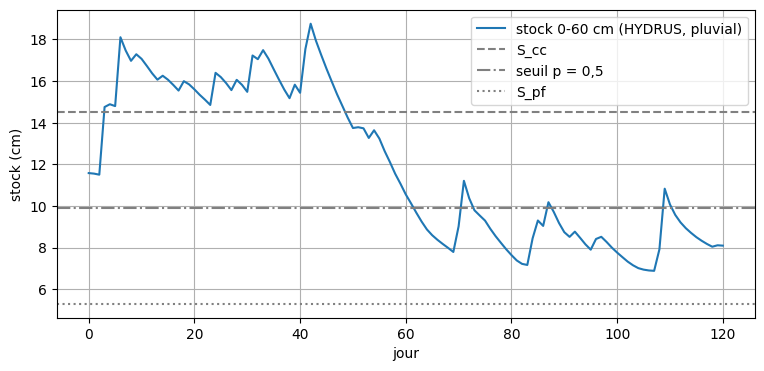

In [17]:
# teneur en eau à la fin de chaque jour aux trois nœuds de la zone racinaire
th10_j = np.interp(jours_fin, ob.index, ob[(11, "theta")])
th30_j = np.interp(jours_fin, ob.index, ob[(31, "theta")])
th60_j = np.interp(jours_fin, ob.index, ob[(61, "theta")])
S_H = 20 * th10_j + 25 * th30_j + 15 * th60_j      # stock 0-60 cm (cm), simulation pluviale HYDRUS

Zr = 60.0                      # profondeur racinaire (cm)
S_cc = theta_cc * Zr           # stock à la capacité au champ
S_pf = theta_pf * Zr           # stock au point de flétrissement
RU = S_cc - S_pf               # réserve utile
p = 0.5
seuil = S_cc - p * RU          # seuil de déclenchement (S_cc - RFU)
print(f"S_cc = {S_cc:.1f} cm, S_pf = {S_pf:.1f} cm, RU = {RU:.1f} cm, RFU(p=0,5) = {p * RU:.1f} cm")

jours_sous_seuil = jours_fin[S_H < seuil]
print(f"premier franchissement du seuil ({seuil:.1f} cm) au jour", jours_sous_seuil[0])

plt.figure(figsize=(9, 4))
plt.plot(jours_fin, S_H, label="stock 0-60 cm (HYDRUS, pluvial)")
plt.axhline(S_cc, color="gray", linestyle="--", label="S_cc")
plt.axhline(seuil, color="gray", linestyle="-.", label="seuil p = 0,5")
plt.axhline(S_pf, color="gray", linestyle=":", label="S_pf")
plt.xlabel("jour")
plt.ylabel("stock (cm)")
plt.legend()
plt.grid(True)
plt.show()

**2. Calendrier d'irrigation pour p = 0,5**

   jour  dose_mm  dose_brute_mm
0    62     48.5           57.1
1    79     48.7           57.3
2   100     49.4           58.2
p = 0,5 : 3 irrigations, volume net 147 mm = 1467 m³/ha ; brut (eff. 0,85) 173 mm


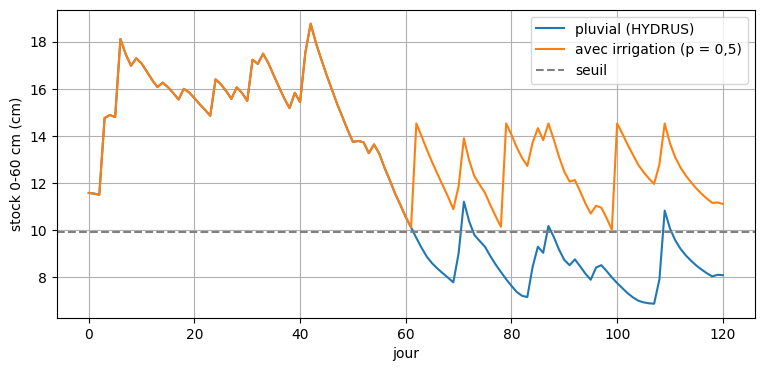

In [18]:
dS_H = np.diff(S_H)            # variation journalière du stock dans la simulation pluviale (cm)
efficience = 0.85              # efficience de l'irrigation (dose brute = dose nette / efficience)

S = S_H[0]
irrigue = False                # devient vrai après la première irrigation
jours_irrig = []
doses_mm = []
S_irrig = [S]                  # trajectoire du stock avec irrigation
for j in range(120):
    if irrigue:
        # après irrigation : la culture transpire à Tp, l'excédent au-dessus de S_cc draine
        dS = dS_H[j] - (Tp_j[j] - Ta_j[j])
        S = min(S + dS, S_cc)
    else:
        # avant la première irrigation : trajectoire HYDRUS
        S = S_H[j + 1]
    # seuil atteint pendant que la culture est active : on irrigue du déficit
    if S < seuil and Tp_j[j] > 0.1:
        dose = S_cc - S
        jours_irrig.append(j + 1)
        doses_mm.append(10 * dose)
        S = S_cc
        irrigue = True
    S_irrig.append(S)

calendrier = pd.DataFrame({"jour": jours_irrig, "dose_mm": doses_mm})
calendrier["dose_brute_mm"] = calendrier["dose_mm"] / efficience
print(calendrier.round(1))
volume_net = calendrier["dose_mm"].sum()
volume_brut = calendrier["dose_brute_mm"].sum()
print(f"p = 0,5 : {len(calendrier)} irrigations, volume net {volume_net:.0f} mm = {10 * volume_net:.0f} m³/ha ; brut (eff. 0,85) {volume_brut:.0f} mm")

plt.figure(figsize=(9, 4))
plt.plot(jours_fin, S_H, label="pluvial (HYDRUS)")
plt.plot(jours_fin, S_irrig, label="avec irrigation (p = 0,5)")
plt.axhline(seuil, color="gray", linestyle="--", label="seuil")
plt.xlabel("jour")
plt.ylabel("stock 0-60 cm (cm)")
plt.legend()
plt.grid(True)
plt.show()

**3. Sensibilité au seuil p**

In [19]:
resultats = []
for p_cas in [0.3, 0.5, 0.7]:
    seuil_cas = S_cc - p_cas * RU
    S = S_H[0]
    irrigue = False
    doses_cas = []
    jours_cas = []
    for j in range(120):
        if irrigue:
            dS = dS_H[j] - (Tp_j[j] - Ta_j[j])
            S = min(S + dS, S_cc)
        else:
            S = S_H[j + 1]
        if S < seuil_cas and Tp_j[j] > 0.1:
            dose = S_cc - S
            jours_cas.append(j + 1)
            doses_cas.append(10 * dose)
            S = S_cc
            irrigue = True
    resultats.append(dict(p=p_cas, n_irrigations=len(doses_cas), dose_moy_mm=np.mean(doses_cas), volume_mm=np.sum(doses_cas),
                          premiere=min(jours_cas), derniere=max(jours_cas)))
print(pd.DataFrame(resultats).round(1))

     p  n_irrigations  dose_moy_mm  volume_mm  premiere  derniere
0  0.3              7         29.5      206.7        58       116
1  0.5              3         48.9      146.7        62       100
2  0.7              2         65.2      130.3        68        91


**Commentaire (instructeur).** Le seuil $p = 0{,}5$ (RFU ≈ 46 mm) est franchi au jour 62 ; il faut ensuite trois apports d'environ 49 mm (jours 62, 79, 100), soit
≈ 150 mm nets (1500 m³/ha, 170 mm bruts à 85 % d'efficience), un complément modeste pour un maïs en climat tempéré humide (392 mm de pluie).
Un $p$ faible (0,3) multiplie les petits apports (bon pour l'aspersion pivot ou le goutte-à-goutte), un $p$ élevé (0,7) laisse la culture
subir un stress avant chaque apport : pour le maïs en floraison, on retient $p \le 0{,}5$. Le calendrier reste indicatif : il suppose
que l'irrigation rétablit $T_a = T_p$ sans changer $E_a$ ni le drainage ; une simulation HYDRUS avec irrigation (voir « Pour aller plus loin »)
lève cette hypothèse.

## Exercice 5 — Bonus — modèle de bilan à un réservoir  *(≈ facultatif)*

Écrire un modèle journalier à un réservoir (zone racinaire 0–60 cm, réserve utile $RU$) :
$S_{t} = S_{t-1} + P_t + I_{r,t} - E_{a,t} - T_{a,t} - D_t$ avec $T_a = T_p\min(1, S/((1-p)RU))$ (FAO-56, $p = 0{,}5$),
$E_a = E_p\min(1, S/RU)$, $D = \max(0, S - RU)$ ($S$ = eau disponible au-dessus de $\theta_{pf}$).
Initialiser avec $\theta_0 = \theta(-200$ cm$)$.

1. Simuler la saison pluviale et comparer $T_a$, $E_a$, $D$ cumulés et $T_a/T_p$ à HYDRUS.
2. Rejouer avec le calendrier d'irrigation de l'exercice 4 ($p = 0{,}5$) et comparer l'indice de stress journalier.

**1. Réservoir en pluvial**

In [20]:
P_j = met["pluie_mm"].to_numpy() / 10     # pluie journalière (cm)
Ep_j = met["Ep_mm"].to_numpy() / 10       # évaporation potentielle journalière (cm)
theta_0 = vg_theta(-200, thr_loam, ths_loam, alpha_loam, n_loam)
S0 = (theta_0 - theta_pf) * Zr            # eau disponible initiale au-dessus du point de flétrissement (cm)

S = S0
Ea_res = np.zeros(120)
Ta_res = np.zeros(120)
D_res = np.zeros(120)
for j in range(120):
    Ta_res[j] = Tp_j[j] * min(1.0, S / ((1 - p) * RU))
    Ea_res[j] = Ep_j[j] * min(1.0, S / RU)
    S = S + P_j[j] - Ea_res[j] - Ta_res[j]
    if S > RU:
        D_res[j] = S - RU
        S = RU

print(f"HYDRUS (pluvial)    : Ea = {Ea:.2f} cm, Ta = {Ta:.2f} cm, D = {Dr:.2f} cm, Ta/Tp = {Ta / Tp_tot:.2f}")
print(f"réservoir (pluvial) : Ea = {Ea_res.sum():.2f} cm, Ta = {Ta_res.sum():.2f} cm, D = {D_res.sum():.2f} cm, Ta/Tp = {Ta_res.sum() / Tp_j.sum():.2f}")

HYDRUS (pluvial)    : Ea = 12.31 cm, Ta = 26.53 cm, D = 2.29 cm, Ta/Tp = 0.71
réservoir (pluvial) : Ea = 8.68 cm, Ta = 25.34 cm, D = 8.34 cm, Ta/Tp = 0.68


**2. Réservoir avec le calendrier d'irrigation**

réservoir + irrigation : Ea = 10.82 cm, Ta = 35.39 cm, D = 8.34 cm, Ta/Tp = 0.95


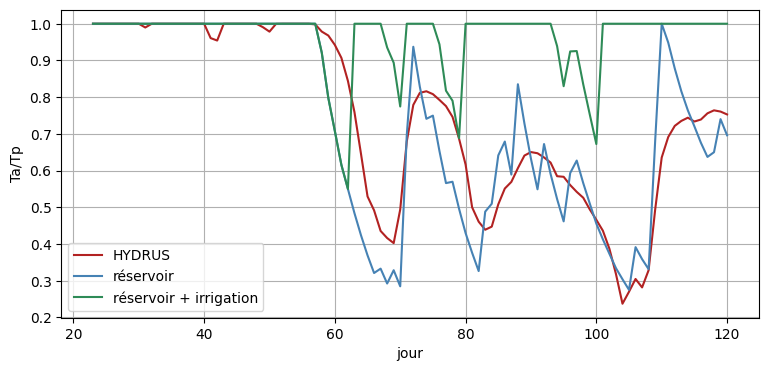

In [21]:
# irrigation journalière (cm) : nulle sauf aux jours du calendrier p = 0,5 de l'exercice 4
Ir_j = np.zeros(120)
for i in range(len(jours_irrig)):
    Ir_j[jours_irrig[i] - 1] = doses_mm[i] / 10

S = S0
Ea_irr = np.zeros(120)
Ta_irr = np.zeros(120)
D_irr = np.zeros(120)
for j in range(120):
    Ta_irr[j] = Tp_j[j] * min(1.0, S / ((1 - p) * RU))
    Ea_irr[j] = Ep_j[j] * min(1.0, S / RU)
    S = S + P_j[j] + Ir_j[j] - Ea_irr[j] - Ta_irr[j]
    if S > RU:
        D_irr[j] = S - RU
        S = RU
print(f"réservoir + irrigation : Ea = {Ea_irr.sum():.2f} cm, Ta = {Ta_irr.sum():.2f} cm, D = {D_irr.sum():.2f} cm, Ta/Tp = {Ta_irr.sum() / Tp_j.sum():.2f}")

# indice de stress journalier des deux réservoirs
ratio_res = np.full(120, np.nan)
ratio_irr = np.full(120, np.nan)
for j in range(120):
    if Tp_j[j] > 0.05:
        ratio_res[j] = Ta_res[j] / Tp_j[j]
        ratio_irr[j] = Ta_irr[j] / Tp_j[j]

plt.figure(figsize=(9, 4))
plt.plot(jours, ratio, color="firebrick", label="HYDRUS")
plt.plot(jours, ratio_res, color="steelblue", label="réservoir")
plt.plot(jours, ratio_irr, color="seagreen", label="réservoir + irrigation")
plt.xlabel("jour")
plt.ylabel("Ta/Tp")
plt.legend()
plt.grid(True)
plt.show()

**Commentaire (instructeur).** Le réservoir retrouve $T_a$ (25,3 contre 26,5 cm) et le calendrier des stress, mais sous-estime $E_a$ (8,7 contre 12,3 cm : pas de stade 2
explicite) et surestime le drainage (8,3 contre 2,3 cm) : toute l'eau au-delà de $RU$ est perdue immédiatement, alors qu'HYDRUS la stocke
sous 60 cm, la laisse drainer lentement (exercice 1) et la restitue en partie par remontée capillaire. Avec le calendrier de l'exercice 4,
$T_a/T_p$ remonte à 0,95 : l'objectif de la règle est atteint. C'est l'outil de pilotage courant ; HYDRUS
sert à le caler (RU, $p$) et à vérifier le drainage et le lessivage.

## Pour aller plus loin

* Refaire l'exercice 1 avec un profil stratifié (loam sur sable, J7) : comment la barrière capillaire modifie-t-elle $\theta_{cc}$ ?
* Comparer la solution de Kirchhoff (exercice 2) à une simulation HYDRUS-1D d'évaporation (condition atmosphérique, `hCritA` = $10^6$ cm).
* Dans HYDRUS-1D, ajouter les irrigations de l'exercice 4 à `Prec` dans `ATMOSPH.IN` et comparer $T_a/T_p$, drainage et stock.